# Same-backend IBM Quantum verification for canonical and noncanonical resources

This notebook combines the canonical $(M_1,M_2)=(0,0)$ and noncanonical
$(M_1,M_2)=(0,1)$ experiments into one reproducible workflow. It is designed
to address the remaining process-characterization concern in the manuscript:

1. both resources are compiled for and submitted to the **same IBM backend**;
2. state tomography tests every $(x,m)$ sector with the nonsymmetric complex input
   $\sqrt{0.7}|00\rangle+e^{i\pi/3}\sqrt{0.3}|11\rangle$;
3. four logical probes directly reconstruct the **unnormalized trace-non-increasing
   code-space suboperation** for each resource;
4. a convex fit enforces complete positivity and trace non-increase (CP-TNI);
5. multinomial bootstrap intervals quantify finite-shot uncertainty for the
   process-level estimators.

All displayed text, table headings, figure labels, and saved filenames are in
English. The real-hardware submission cell is disabled by default.

## 1. Install the required packages

Run this cell once. Restart the kernel if imports fail immediately after installation.

In [1]:
%pip install --upgrade "qiskit[visualization]>=2.5,<3" "qiskit-aer>=0.17,<1" "qiskit-ibm-runtime>=0.47,<1" "cvxpy>=1.6,<2" "pandas>=2,<4" "matplotlib>=3.8,<4"

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and experiment configuration

`HARDWARE_PROCESS_BOOTSTRAP_SAMPLES=500` matches the state-level uncertainty
analysis already used in the manuscript. The smaller local value keeps the
simulator validation quick.

In [2]:
import json
import platform
from collections import Counter
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler

print("Python:", platform.python_version())
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)
print("CVXPY:", cp.__version__)

Python: 3.12.11
Qiskit: 2.5.2
Qiskit Aer: 0.17.2
Qiskit IBM Runtime: 0.49.0
CVXPY: 1.9.2


In [3]:
INPUT_PROBABILITY_00 = 0.7
INPUT_PHASE = np.pi / 3
Y_SECTOR = 0

RESOURCES = {
    "canonical": {"M1": 0, "M2": 0, "process_case": (1, 0)},
    "noncanonical": {"M1": 0, "M2": 1, "process_case": (0, 0)},
}
CASES = [(0, 0), (1, 0), (0, 1), (1, 1)]
PROCESS_INPUTS = ("zero", "one", "plus", "plus_i")

LOCAL_SHOTS = 4096
HARDWARE_SHOTS = 4096
HARDWARE_REPEATS = 1
LOCAL_STATE_BOOTSTRAP_SAMPLES = 40
LOCAL_PROCESS_BOOTSTRAP_SAMPLES = 30
HARDWARE_STATE_BOOTSTRAP_SAMPLES = 500
HARDWARE_PROCESS_BOOTSTRAP_SAMPLES = 500
RANDOM_SEED = 240917

RUN_LOCAL_VALIDATION = True
# Optional: set an exact IBM backend name, or leave blank for least-busy selection.
BACKEND_NAME = ""
OUTPUT_DIR = Path.cwd() / "canonical_noncanonical_cptni_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "savefig.dpi": 300,
})
print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\hideok34\canonical_noncanonical_cptni_results


## 3. Five-qubit circuit and family-wide recovery

The resource on $(q_4,q_3,q_2)$ is

$$|G_{m;M_1,M_2}\rangle=
\frac{|M_2,M_1,0\rangle+(-1)^m|\bar M_2,\bar M_1,1\rangle}{\sqrt2}.$$

In receiver order $(q_4,q_3)$, the predicted raw frame is

$$C_{x,m}^{(M_1,M_2)}=X^{m\oplus x}\otimes
X^{m\oplus M_1\oplus M_2}Z^{M_2}.$$

The physical recovery appends the inverse frame. On $q_3$, the circuit-time gate
order is first $X^{m\oplus M_1\oplus M_2}$ and then $Z^{M_2}$.

In [4]:
I2 = np.eye(2, dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X2, "Y": Y2, "Z": Z2}
PAULI_LABELS = ("I", "X", "Y", "Z")
TOMOGRAPHY_BASES = ("X", "Y", "Z")


def prepare_logical_input(circuit, qubits, state_label="custom", y=Y_SECTOR):
    q0, q1 = qubits[0], qubits[1]
    if state_label == "custom":
        theta = 2 * np.arccos(np.sqrt(INPUT_PROBABILITY_00))
        circuit.ry(theta, q0)
        circuit.p(INPUT_PHASE, q0)
    elif state_label == "zero":
        pass
    elif state_label == "one":
        circuit.x(q0)
    elif state_label == "plus":
        circuit.h(q0)
    elif state_label == "plus_i":
        circuit.h(q0)
        circuit.s(q0)
    else:
        raise ValueError(f"Unknown logical input: {state_label}")
    if y:
        circuit.x(q1)
    circuit.cx(q0, q1)


def prepare_ghz_resource(circuit, qubits, m, M1, M2):
    q2, q3, q4 = qubits[2], qubits[3], qubits[4]
    if m:
        circuit.x(q2)
    circuit.h(q2)
    if M1:
        circuit.x(q3)
    if M2:
        circuit.x(q4)
    circuit.cx(q2, q3)
    circuit.cx(q2, q4)


def append_transfer_network(circuit, qubits, x, m):
    q0, q1, q2, q3, q4 = qubits
    z = m ^ x
    circuit.barrier()
    circuit.h(q1)
    circuit.cx(q1, q2)
    circuit.h(q1)
    circuit.cx(q2, q3)
    circuit.barrier()
    circuit.h(q3)
    if m:
        circuit.x(q3)
    circuit.cx(q1, q3)
    circuit.h(q3)
    if m:
        circuit.x(q3)
    circuit.barrier()
    circuit.cx(q2, q4)
    circuit.cx(q4, q3)
    circuit.barrier()
    circuit.cx(q0, q3)
    circuit.h(q4)
    if z:
        circuit.x(q4)
    circuit.cx(q4, q0)
    circuit.barrier()


def append_receiver_recovery(circuit, qubits, x, m, M1, M2):
    q3, q4 = qubits[3], qubits[4]
    z = m ^ x
    k = m ^ M1 ^ M2
    if z:
        circuit.x(q4)
    if k:
        circuit.x(q3)
    if M2:
        circuit.z(q3)
    circuit.barrier()


def build_transfer_circuit(x, m, M1, M2, recovered=False, state_label="custom"):
    q = QuantumRegister(5, "q")
    mode = "recovered" if recovered else "raw"
    name = f"M1{M1}_M2{M2}_x{x}_m{m}_{state_label}_{mode}"
    circuit = QuantumCircuit(q, name=name)
    prepare_logical_input(circuit, q, state_label=state_label)
    prepare_ghz_resource(circuit, q, m=m, M1=M1, M2=M2)
    append_transfer_network(circuit, q, x=x, m=m)
    if recovered:
        append_receiver_recovery(circuit, q, x=x, m=m, M1=M1, M2=M2)
    return circuit


def input_ket(state_label="custom"):
    if state_label == "custom":
        alpha = np.sqrt(INPUT_PROBABILITY_00)
        beta = np.exp(1j * INPUT_PHASE) * np.sqrt(1 - INPUT_PROBABILITY_00)
        return np.array([alpha, 0, 0, beta], dtype=complex)
    logical_vectors = {
        "zero": np.array([1, 0], dtype=complex),
        "one": np.array([0, 1], dtype=complex),
        "plus": np.array([1, 1], dtype=complex) / np.sqrt(2),
        "plus_i": np.array([1, 1j], dtype=complex) / np.sqrt(2),
    }
    logical = logical_vectors[state_label]
    return np.array([logical[0], 0, 0, logical[1]], dtype=complex)


def receiver_frame(x, m, M1, M2):
    z = m ^ x
    k = m ^ M1 ^ M2
    q4_factor = X2 if z else I2
    q3_factor = (X2 if k else I2) @ (Z2 if M2 else I2)
    return np.kron(q4_factor, q3_factor)


def pure_state_fidelity(rho, ket):
    return float(np.clip(np.real(np.vdot(ket, rho @ ket)), 0.0, 1.0))

In [5]:
ideal_rows = []
target = input_ket("custom")
for resource_name, resource in RESOURCES.items():
    M1, M2 = resource["M1"], resource["M2"]
    for x, m in CASES:
        frame = receiver_frame(x, m, M1, M2)
        for recovered in (False, True):
            circuit = build_transfer_circuit(x, m, M1, M2, recovered=recovered)
            full_state = Statevector.from_instruction(circuit)
            receiver_state = partial_trace(full_state, [0, 1, 2]).data
            expected = target if recovered else frame @ target
            ideal_rows.append({
                "resource": resource_name,
                "M1": M1,
                "M2": M2,
                "case": f"({x},{m})",
                "mode": "recovered" if recovered else "raw",
                "fidelity_to_theorem_prediction": pure_state_fidelity(receiver_state, expected),
            })
ideal_check = pd.DataFrame(ideal_rows)
display(ideal_check.round(12))
assert ideal_check["fidelity_to_theorem_prediction"].min() > 1 - 1e-10
print("Ideal family-wide circuit check passed.")

,resource,M1,M2,case,mode,fidelity_to_theorem_prediction
0,canonical,0,0,"(0,0)",raw,1.0
1,canonical,0,0,"(0,0)",recovered,1.0
2,canonical,0,0,"(1,0)",raw,1.0
3,canonical,0,0,"(1,0)",recovered,1.0
4,canonical,0,0,"(0,1)",raw,1.0
5,canonical,0,0,"(0,1)",recovered,1.0
6,canonical,0,0,"(1,1)",raw,1.0
7,canonical,0,0,"(1,1)",recovered,1.0
8,noncanonical,0,1,"(0,0)",raw,1.0
9,noncanonical,0,1,"(0,0)",recovered,1.0


Ideal family-wide circuit check passed.


## 4. Receiver tomography and combined experiment manifest

Each receiver state uses the nine local settings `XX, XY, XZ, YX, YY, YZ,
ZX, ZY, ZZ`. The classical bit string is interpreted as `q4 q3`.

In [6]:
def append_basis_measurement(circuit, basis_q4, basis_q3):
    measured = circuit.copy()
    q3, q4 = measured.qubits[3], measured.qubits[4]
    for qubit, basis in ((q4, basis_q4), (q3, basis_q3)):
        if basis == "X":
            measured.h(qubit)
        elif basis == "Y":
            measured.sdg(qubit)
            measured.h(qubit)
        elif basis != "Z":
            raise ValueError(f"Unsupported basis: {basis}")
    meas = ClassicalRegister(2, "meas")
    measured.add_register(meas)
    measured.measure(q3, meas[0])
    measured.measure(q4, meas[1])
    return measured


def build_combined_experiments():
    records, circuits = [], []
    for resource_name, resource in RESOURCES.items():
        M1, M2 = resource["M1"], resource["M2"]
        for x, m in CASES:
            for recovered in (False, True):
                mode = "recovered" if recovered else "raw"
                base = build_transfer_circuit(x, m, M1, M2, recovered=recovered)
                for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
                    circuit = append_basis_measurement(base, basis_q4, basis_q3)
                    circuit.name = f"state_{resource_name}_x{x}_m{m}_{mode}_{basis_q4}{basis_q3}"
                    records.append({
                        "experiment": "state",
                        "resource": resource_name,
                        "M1": M1,
                        "M2": M2,
                        "logical_input": "custom",
                        "x": x,
                        "m": m,
                        "mode": mode,
                        "basis_q4": basis_q4,
                        "basis_q3": basis_q3,
                        "circuit_name": circuit.name,
                    })
                    circuits.append(circuit)
        x, m = resource["process_case"]
        for state_label in PROCESS_INPUTS:
            base = build_transfer_circuit(
                x, m, M1, M2, recovered=True, state_label=state_label
            )
            for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
                circuit = append_basis_measurement(base, basis_q4, basis_q3)
                circuit.name = f"process_{resource_name}_x{x}_m{m}_{state_label}_{basis_q4}{basis_q3}"
                records.append({
                    "experiment": "process",
                    "resource": resource_name,
                    "M1": M1,
                    "M2": M2,
                    "logical_input": state_label,
                    "x": x,
                    "m": m,
                    "mode": "recovered",
                    "basis_q4": basis_q4,
                    "basis_q3": basis_q3,
                    "circuit_name": circuit.name,
                })
                circuits.append(circuit)
    return records, circuits


combined_records, combined_circuits = build_combined_experiments()
manifest = pd.DataFrame(combined_records)
display(manifest.groupby(["experiment", "resource"]).size().rename("circuits"))
print("Combined circuits per repeat:", len(combined_circuits))
print("Shots per repeat:", len(combined_circuits) * HARDWARE_SHOTS)
assert len(combined_circuits) == 216

experiment  resource    
process     canonical       36
            noncanonical    36
state       canonical       72
            noncanonical    72
Name: circuits, dtype: int64

Combined circuits per repeat: 216
Shots per repeat: 884736


In [7]:
def normalized_two_bit_counts(counts):
    cleaned = Counter()
    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "").zfill(2)[-2:]
        cleaned[bits] += int(count)
    return dict(cleaned)


def measurement_moments(counts):
    counts = normalized_two_bit_counts(counts)
    shots = sum(counts.values())
    if shots == 0:
        raise ValueError("A tomography setting has zero shots.")
    e_q4 = e_q3 = e_q4_q3 = 0.0
    for bits, count in counts.items():
        value_q4 = 1 if bits[0] == "0" else -1
        value_q3 = 1 if bits[1] == "0" else -1
        e_q4 += value_q4 * count
        e_q3 += value_q3 * count
        e_q4_q3 += value_q4 * value_q3 * count
    return e_q4 / shots, e_q3 / shots, e_q4_q3 / shots


def project_to_density_matrix(matrix):
    matrix = (matrix + matrix.conj().T) / 2
    matrix = matrix / np.trace(matrix)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    ordered = np.sort(eigenvalues)[::-1]
    cumulative = np.cumsum(ordered) - 1.0
    positive = np.nonzero(
        ordered - cumulative / np.arange(1, len(ordered) + 1) > 0
    )[0]
    threshold = cumulative[positive[-1]] / (positive[-1] + 1)
    projected_values = np.maximum(eigenvalues - threshold, 0.0)
    projected = eigenvectors @ np.diag(projected_values) @ eigenvectors.conj().T
    return (projected + projected.conj().T) / 2


def reconstruct_two_qubit_state(counts_by_basis):
    moments = {basis: measurement_moments(counts) for basis, counts in counts_by_basis.items()}
    expectations = {("I", "I"): 1.0}
    for basis_q4 in TOMOGRAPHY_BASES:
        expectations[(basis_q4, "I")] = float(np.mean([
            moments[(basis_q4, basis_q3)][0] for basis_q3 in TOMOGRAPHY_BASES
        ]))
    for basis_q3 in TOMOGRAPHY_BASES:
        expectations[("I", basis_q3)] = float(np.mean([
            moments[(basis_q4, basis_q3)][1] for basis_q4 in TOMOGRAPHY_BASES
        ]))
    for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
        expectations[(basis_q4, basis_q3)] = moments[(basis_q4, basis_q3)][2]
    rho_linear = np.zeros((4, 4), dtype=complex)
    for p4, p3 in product(PAULI_LABELS, repeat=2):
        rho_linear += expectations[(p4, p3)] * np.kron(PAULI[p4], PAULI[p3])
    rho_linear /= 4
    return rho_linear, project_to_density_matrix(rho_linear), expectations


def group_tomography_counts(records, counts_list, key_fields):
    groups = {}
    for record, counts in zip(records, counts_list):
        key = tuple(record[field] for field in key_fields)
        basis = (record["basis_q4"], record["basis_q3"])
        groups.setdefault(key, {})[basis] = normalized_two_bit_counts(counts)
    return groups


def resample_counts(counts, rng):
    counts = normalized_two_bit_counts(counts)
    keys = sorted(counts)
    n = sum(counts.values())
    probabilities = np.array([counts[key] for key in keys], dtype=float) / n
    sample = rng.multinomial(n, probabilities)
    return {key: int(value) for key, value in zip(keys, sample) if value}


def merge_count_dictionaries(dictionaries):
    merged = Counter()
    for counts in dictionaries:
        merged.update(normalized_two_bit_counts(counts))
    return dict(merged)


def pool_repeated_counts(repeated_counts):
    return [
        merge_count_dictionaries([repeat[index] for repeat in repeated_counts])
        for index in range(len(repeated_counts[0]))
    ]

## 5. State-level analysis

The state analysis is retained to reproduce the canonical and phase-sensitive
noncanonical checks. Its intervals describe finite-shot uncertainty only.

In [8]:
def analyze_state_tomography(records, counts_list, bootstrap_samples):
    selected = [(r, c) for r, c in zip(records, counts_list) if r["experiment"] == "state"]
    state_records = [item[0] for item in selected]
    state_counts = [item[1] for item in selected]
    groups = group_tomography_counts(
        state_records, state_counts, ("resource", "x", "m", "mode")
    )
    target_state = input_ket("custom")
    rows, densities = [], {}
    for resource_name, resource in RESOURCES.items():
        M1, M2 = resource["M1"], resource["M2"]
        for x, m in CASES:
            _, raw, _ = reconstruct_two_qubit_state(groups[(resource_name, x, m, "raw")])
            _, recovered, _ = reconstruct_two_qubit_state(groups[(resource_name, x, m, "recovered")])
            frame = receiver_frame(x, m, M1, M2)
            tracked = frame.conj().T @ raw @ frame
            predicted_raw = frame @ target_state
            row = {
                "resource": resource_name,
                "M1": M1,
                "M2": M2,
                "case": f"({x},{m})",
                "x": x,
                "m": m,
                "raw_fidelity_to_input": pure_state_fidelity(raw, target_state),
                "raw_fidelity_to_predicted_frame": pure_state_fidelity(raw, predicted_raw),
                "frame_tracked_fidelity_to_input": pure_state_fidelity(tracked, target_state),
                "recovered_fidelity_to_input": pure_state_fidelity(recovered, target_state),
                "recovered_code_population": float(np.real(recovered[0, 0] + recovered[3, 3])),
                "recovered_purity": float(np.real(np.trace(recovered @ recovered))),
                "recovered_coherence_real": float(np.real(recovered[0, 3])),
                "recovered_coherence_imag": float(np.imag(recovered[0, 3])),
            }
            rng = np.random.default_rng(RANDOM_SEED + 1000 * M2 + 100 * x + 10 * m)
            boot = {name: [] for name in (
                "raw_fidelity_to_predicted_frame",
                "frame_tracked_fidelity_to_input",
                "recovered_fidelity_to_input",
            )}
            for _ in range(bootstrap_samples):
                raw_sample = {b: resample_counts(c, rng) for b, c in groups[(resource_name, x, m, "raw")].items()}
                rec_sample = {b: resample_counts(c, rng) for b, c in groups[(resource_name, x, m, "recovered")].items()}
                _, raw_b, _ = reconstruct_two_qubit_state(raw_sample)
                _, rec_b, _ = reconstruct_two_qubit_state(rec_sample)
                track_b = frame.conj().T @ raw_b @ frame
                boot["raw_fidelity_to_predicted_frame"].append(pure_state_fidelity(raw_b, predicted_raw))
                boot["frame_tracked_fidelity_to_input"].append(pure_state_fidelity(track_b, target_state))
                boot["recovered_fidelity_to_input"].append(pure_state_fidelity(rec_b, target_state))
            for metric, values in boot.items():
                row[f"{metric}_ci95_low"] = float(np.quantile(values, 0.025))
                row[f"{metric}_ci95_high"] = float(np.quantile(values, 0.975))
            rows.append(row)
            densities[(resource_name, x, m)] = {
                "raw": raw,
                "frame_tracked": tracked,
                "recovered": recovered,
            }
    return pd.DataFrame(rows), densities

## 6. Direct linear and CP-TNI process reconstruction

For each logical probe $s\in\{0,1,+,+i\}$, receiver tomography produces a
normalized two-qubit state. The unnormalized logical code block is

$$B_s=V_0^\dagger P_0\rho_{\mathrm{out}}^{(s)}P_0V_0,$$

and its trace is the measured code-space survival. The direct linear estimate
uses

$$\mathcal E(I)=B_0+B_1,\quad \mathcal E(Z)=B_0-B_1,$$
$$\mathcal E(X)=2B_+-B_0-B_1,\quad
  \mathcal E(Y)=2B_{+i}-B_0-B_1.$$

The constrained estimate fits one Choi matrix $J$ to all four $B_s$ under
$J\succeq0$ and $\operatorname{Tr}_{\mathrm{out}}J\preceq I$. No probe output
is normalized separately. The reported identity metric is
$D_{\mathrm{id}}^{(\mathrm{TNI})}=\operatorname{Tr}(R)/4$; it is not labeled as
a CPTP process fidelity.

In [9]:
INPUT_DENSITIES = {
    "zero": np.array([[1, 0], [0, 0]], dtype=complex),
    "one": np.array([[0, 0], [0, 1]], dtype=complex),
    "plus": 0.5 * np.array([[1, 1], [1, 1]], dtype=complex),
    "plus_i": 0.5 * np.array([[1, -1j], [1j, 1]], dtype=complex),
}


def code_block(receiver_density):
    return receiver_density[np.ix_([0, 3], [0, 3])]


def linear_choi_from_blocks(blocks):
    B0, B1 = blocks["zero"], blocks["one"]
    EI = B0 + B1
    EZ = B0 - B1
    EX = 2 * blocks["plus"] - EI
    EY = 2 * blocks["plus_i"] - EI
    E01 = (EX + 1j * EY) / 2
    E10 = (EX - 1j * EY) / 2
    return np.block([[B0, E01], [E10, B1]])


def partial_trace_output(choi):
    return np.array([
        [np.trace(choi[0:2, 0:2]), np.trace(choi[0:2, 2:4])],
        [np.trace(choi[2:4, 0:2]), np.trace(choi[2:4, 2:4])],
    ], dtype=complex)


def apply_choi(choi, rho):
    output = np.zeros((2, 2), dtype=complex)
    for i, j in product(range(2), repeat=2):
        output += rho[i, j] * choi[2*i:2*i+2, 2*j:2*j+2]
    return output


def ptm_from_choi(choi):
    ptm = np.zeros((4, 4), dtype=float)
    for nu, input_pauli in enumerate(PAULI_LABELS):
        output = apply_choi(choi, PAULI[input_pauli])
        for mu, output_pauli in enumerate(PAULI_LABELS):
            ptm[mu, nu] = float(np.real(np.trace(PAULI[output_pauli] @ output)) / 2)
    return ptm


def fit_cptni_choi(blocks, solver=cp.SCS):
    J = cp.Variable((4, 4), hermitian=True)
    residuals = []
    for label, rho in INPUT_DENSITIES.items():
        prediction = sum(
            (rho[i, j] * J[2*i:2*i+2, 2*j:2*j+2] for i, j in product(range(2), repeat=2)),
            cp.Constant(np.zeros((2, 2), dtype=complex)),
        )
        residuals.append(cp.sum_squares(cp.abs(prediction - blocks[label])))
    ptr_out = cp.bmat([
        [cp.trace(J[0:2, 0:2]), cp.trace(J[0:2, 2:4])],
        [cp.trace(J[2:4, 0:2]), cp.trace(J[2:4, 2:4])],
    ])
    constraints = [
        J >> 0,
        np.eye(2) - cp.hermitian_wrap(ptr_out) >> 0,
    ]
    problem = cp.Problem(cp.Minimize(cp.sum(residuals)), constraints)
    problem.solve(solver=solver, eps=1e-7, max_iters=30000, warm_start=True, verbose=False)
    if problem.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        raise RuntimeError(f"CP-TNI fit failed: {problem.status}")
    fitted = np.asarray(J.value, dtype=complex)
    fitted = (fitted + fitted.conj().T) / 2
    return fitted, problem.status, float(problem.value)


def map_metrics(choi):
    choi = (choi + choi.conj().T) / 2
    ptm = ptm_from_choi(choi)
    effect = partial_trace_output(choi).T
    effect = (effect + effect.conj().T) / 2
    return {
        "ptm": ptm,
        "effect": effect,
        "mean_survival": float(ptm[0, 0]),
        "survival_weighted_identity_overlap": float(np.trace(ptm) / 4),
        "minimum_choi_eigenvalue": float(np.linalg.eigvalsh(choi).min()),
        "maximum_effect_eigenvalue": float(np.linalg.eigvalsh(effect).max()),
        "minimum_effect_eigenvalue": float(np.linalg.eigvalsh(effect).min()),
    }


def reconstruct_process_resource(records, counts_list, resource_name):
    selected = [
        (r, c) for r, c in zip(records, counts_list)
        if r["experiment"] == "process" and r["resource"] == resource_name
    ]
    process_records = [item[0] for item in selected]
    process_counts = [item[1] for item in selected]
    groups = group_tomography_counts(process_records, process_counts, ("logical_input",))
    receiver_states, blocks = {}, {}
    for label in PROCESS_INPUTS:
        _, receiver, _ = reconstruct_two_qubit_state(groups[(label,)])
        receiver_states[label] = receiver
        blocks[label] = code_block(receiver)
    linear_choi = linear_choi_from_blocks(blocks)
    cptni_choi, status, objective = fit_cptni_choi(blocks)
    return {
        "blocks": blocks,
        "receiver_states": receiver_states,
        "groups": groups,
        "linear_choi": linear_choi,
        "cptni_choi": cptni_choi,
        "linear": map_metrics(linear_choi),
        "cptni": map_metrics(cptni_choi),
        "solver_status": status,
        "least_squares_objective": objective,
    }


def bootstrap_process_resource(records, counts_list, resource_name, samples):
    selected = [
        (r, c) for r, c in zip(records, counts_list)
        if r["experiment"] == "process" and r["resource"] == resource_name
    ]
    process_records = [item[0] for item in selected]
    process_counts = [item[1] for item in selected]
    base_groups = group_tomography_counts(process_records, process_counts, ("logical_input",))
    seed_offset = 0 if resource_name == "canonical" else 100000
    rng = np.random.default_rng(RANDOM_SEED + seed_offset)
    rows = []
    for sample_index in range(samples):
        blocks = {}
        for label in PROCESS_INPUTS:
            sampled = {basis: resample_counts(counts, rng) for basis, counts in base_groups[(label,)].items()}
            _, receiver, _ = reconstruct_two_qubit_state(sampled)
            blocks[label] = code_block(receiver)
        fitted, status, objective = fit_cptni_choi(blocks)
        metrics = map_metrics(fitted)
        row = {
            "resource": resource_name,
            "bootstrap_sample": sample_index,
            "solver_status": status,
            "least_squares_objective": objective,
            "mean_survival": metrics["mean_survival"],
            "survival_weighted_identity_overlap": metrics["survival_weighted_identity_overlap"],
            "minimum_choi_eigenvalue": metrics["minimum_choi_eigenvalue"],
            "maximum_effect_eigenvalue": metrics["maximum_effect_eigenvalue"],
        }
        for mu, nu in product(range(4), repeat=2):
            row[f"R_{PAULI_LABELS[mu]}{PAULI_LABELS[nu]}"] = metrics["ptm"][mu, nu]
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_process_analyses(analyses, bootstrap_table):
    rows = []
    for resource_name, analysis in analyses.items():
        resource = RESOURCES[resource_name]
        boot = bootstrap_table[bootstrap_table["resource"] == resource_name]
        row = {
            "resource": resource_name,
            "M1": resource["M1"],
            "M2": resource["M2"],
            "process_case": str(resource["process_case"]),
            "linear_mean_survival": analysis["linear"]["mean_survival"],
            "linear_survival_weighted_identity_overlap": analysis["linear"]["survival_weighted_identity_overlap"],
            "linear_minimum_choi_eigenvalue": analysis["linear"]["minimum_choi_eigenvalue"],
            "linear_maximum_effect_eigenvalue": analysis["linear"]["maximum_effect_eigenvalue"],
            "cptni_mean_survival": analysis["cptni"]["mean_survival"],
            "cptni_survival_weighted_identity_overlap": analysis["cptni"]["survival_weighted_identity_overlap"],
            "cptni_minimum_choi_eigenvalue": analysis["cptni"]["minimum_choi_eigenvalue"],
            "cptni_maximum_effect_eigenvalue": analysis["cptni"]["maximum_effect_eigenvalue"],
            "solver_status": analysis["solver_status"],
            "least_squares_objective": analysis["least_squares_objective"],
        }
        for metric in ("mean_survival", "survival_weighted_identity_overlap"):
            row[f"cptni_{metric}_ci95_low"] = float(boot[metric].quantile(0.025))
            row[f"cptni_{metric}_ci95_high"] = float(boot[metric].quantile(0.975))
        rows.append(row)
    return pd.DataFrame(rows)

## 7. Publication-output functions

The three PDF figures are sized for direct manuscript use and are also saved as
300 dpi PNG files. CSV, JSON, and NPZ files retain the numerical results.

In [10]:
RESOURCE_DISPLAY = {
    "canonical": "Canonical (M1, M2) = (0, 0)",
    "noncanonical": "Noncanonical (M1, M2) = (0, 1)",
}


def save_figure(fig, stem):
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path.resolve())
    print("Saved:", pdf_path.resolve())


def plot_cptni_ptms(analyses, prefix):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.55), constrained_layout=True)
    image = None
    for ax, resource_name in zip(axes, ("canonical", "noncanonical")):
        matrix = analyses[resource_name]["cptni"]["ptm"]
        image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(4), PAULI_LABELS)
        ax.set_yticks(range(4), PAULI_LABELS)
        ax.set_xlabel("Input Pauli operator")
        ax.set_ylabel("Output Pauli operator")
        ax.set_title(RESOURCE_DISPLAY[resource_name])
        for row, column in product(range(4), repeat=2):
            color = "white" if abs(matrix[row, column]) > 0.55 else "black"
            ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", color=color, fontsize=8.5)
    fig.colorbar(image, ax=axes, shrink=0.84, label="Pauli transfer coefficient")
    fig.suptitle("CP-TNI code-space suboperation estimates")
    save_figure(fig, f"{prefix}_cptni_ptm_comparison")
    return fig


def plot_cptni_metrics(summary, prefix):
    labels = [RESOURCE_DISPLAY[name] for name in summary["resource"]]
    metrics = [
        ("cptni_mean_survival", "Mean code-space survival", "#4C78A8"),
        ("cptni_survival_weighted_identity_overlap", "Survival-weighted identity overlap", "#F58518"),
    ]
    x = np.arange(len(labels))
    width = 0.34
    fig, ax = plt.subplots(figsize=(7.4, 4.2))
    for offset, (metric, label, color) in zip((-width/2, width/2), metrics):
        values = summary[metric].to_numpy()
        low = summary[f"{metric}_ci95_low"].to_numpy()
        high = summary[f"{metric}_ci95_high"].to_numpy()
        errors = np.vstack([np.maximum(values-low, 0), np.maximum(high-values, 0)])
        bars = ax.bar(x + offset, values, width, yerr=errors, capsize=3, color=color, label=label)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8.5)
    ax.axhline(1, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(x, labels)
    ax.set_ylabel("Estimator value")
    ax.set_ylim(0, 1.10)
    ax.set_title("CP-TNI process estimates with 95% bootstrap intervals")
    ax.legend(frameon=False, loc="lower center")
    ax.grid(axis="y", alpha=0.22)
    fig.tight_layout()
    save_figure(fig, f"{prefix}_cptni_metrics_bootstrap")
    return fig


def plot_physicality(analyses, prefix):
    labels = ["Canonical\n(0, 0)", "Noncanonical\n(0, 1)"]
    names = ("canonical", "noncanonical")
    linear_min = [analyses[name]["linear"]["minimum_choi_eigenvalue"] for name in names]
    cptni_min = [analyses[name]["cptni"]["minimum_choi_eigenvalue"] for name in names]
    linear_max = [analyses[name]["linear"]["maximum_effect_eigenvalue"] for name in names]
    cptni_max = [analyses[name]["cptni"]["maximum_effect_eigenvalue"] for name in names]
    x = np.arange(2)
    width = 0.34
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.65), constrained_layout=True)
    axes[0].bar(x-width/2, linear_min, width, color="#9C755F", label="Linear inversion")
    axes[0].bar(x+width/2, cptni_min, width, color="#59A14F", label="CP-TNI fit")
    axes[0].scatter(x+width/2, cptni_min, color="#2F7D32", marker="D", s=26, zorder=4)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_ylim(min(-0.001, 1.08 * min(linear_min + cptni_min)), 0.001)
    axes[0].set_xticks(x, labels)
    axes[0].set_ylabel("Minimum Choi eigenvalue")
    axes[0].set_title("Complete positivity diagnostic")
    axes[0].grid(axis="y", alpha=0.22)
    axes[1].bar(x-width/2, linear_max, width, color="#9C755F", label="Linear inversion")
    axes[1].bar(x+width/2, cptni_max, width, color="#59A14F", label="CP-TNI fit")
    axes[1].axhline(1, color="black", linewidth=0.8, linestyle="--", label="TNI boundary")
    axes[1].set_xticks(x, labels)
    axes[1].set_ylabel("Maximum effect-operator eigenvalue")
    axes[1].set_title("Trace non-increase diagnostic")
    axes[1].grid(axis="y", alpha=0.22)
    handles, legend_labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, legend_labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle("Physicality diagnostics: linear inversion and CP-TNI fit")
    save_figure(fig, f"{prefix}_cptni_physicality")
    return fig


def save_machine_readable_results(prefix, records, repeated_counts, state_summary, analyses, bootstrap_table, process_summary, metadata):
    state_summary.to_csv(OUTPUT_DIR / f"{prefix}_state_tomography_summary.csv", index=False)
    process_summary.to_csv(OUTPUT_DIR / f"{prefix}_cptni_process_summary.csv", index=False)
    bootstrap_table.to_csv(OUTPUT_DIR / f"{prefix}_cptni_process_bootstrap_samples.csv", index=False)
    ptm_interval_rows = []
    for resource_name, analysis in analyses.items():
        resource_bootstrap = bootstrap_table[bootstrap_table["resource"] == resource_name]
        for mu, nu in product(range(4), repeat=2):
            column = f"R_{PAULI_LABELS[mu]}{PAULI_LABELS[nu]}"
            values = resource_bootstrap[column]
            ptm_interval_rows.append({
                "resource": resource_name,
                "output_pauli": PAULI_LABELS[mu],
                "input_pauli": PAULI_LABELS[nu],
                "point_estimate": analysis["cptni"]["ptm"][mu, nu],
                "bootstrap_ci95_low": float(values.quantile(0.025)),
                "bootstrap_ci95_high": float(values.quantile(0.975)),
            })
    pd.DataFrame(ptm_interval_rows).to_csv(
        OUTPUT_DIR / f"{prefix}_cptni_ptm_bootstrap_ci.csv", index=False
    )
    arrays = {}
    for resource_name, analysis in analyses.items():
        arrays[f"{resource_name}_linear_choi"] = analysis["linear_choi"]
        arrays[f"{resource_name}_cptni_choi"] = analysis["cptni_choi"]
        arrays[f"{resource_name}_linear_ptm"] = analysis["linear"]["ptm"]
        arrays[f"{resource_name}_cptni_ptm"] = analysis["cptni"]["ptm"]
        arrays[f"{resource_name}_cptni_effect"] = analysis["cptni"]["effect"]
        for label, block in analysis["blocks"].items():
            arrays[f"{resource_name}_block_{label}"] = block
    np.savez_compressed(OUTPUT_DIR / f"{prefix}_cptni_matrices.npz", **arrays)
    serialized = []
    for repeat_index, counts_list in enumerate(repeated_counts, start=1):
        serialized.append({
            "repeat": repeat_index,
            "experiments": [
                {**record, "counts": normalized_two_bit_counts(counts)}
                for record, counts in zip(records, counts_list)
            ],
        })
    (OUTPUT_DIR / f"{prefix}_combined_counts.json").write_text(json.dumps(serialized, indent=2), encoding="utf-8")
    (OUTPUT_DIR / f"{prefix}_metadata.json").write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

## 8. Noiseless local validation

This executes all 216 circuits and the constrained reconstruction before any
QPU time is used. With finite shots, small deviations from the ideal identity
are expected. Three English-language manuscript figures are generated.

,resource,M1,M2,case,x,m,raw_fidelity_to_input,raw_fidelity_to_predicted_frame,frame_tracked_fidelity_to_input,recovered_fidelity_to_input,recovered_code_population,recovered_purity,recovered_coherence_real,recovered_coherence_imag,raw_fidelity_to_predicted_frame_ci95_low,raw_fidelity_to_predicted_frame_ci95_high,frame_tracked_fidelity_to_input_ci95_low,frame_tracked_fidelity_to_input_ci95_high,recovered_fidelity_to_input_ci95_low,recovered_fidelity_to_input_ci95_high
0,canonical,0,0,"(0,0)",0,0,0.9919,0.9919,0.9919,0.9991,0.9992,0.9983,0.2287,-0.3979,0.9836,0.9965,0.9836,0.9965,0.9899,0.9999
1,canonical,0,0,"(1,0)",1,0,0.0012,0.9974,0.9974,0.9957,0.9970,0.9918,0.2232,-0.3951,0.9892,0.9997,0.9892,0.9997,0.9875,0.9974
2,canonical,0,0,"(0,1)",0,1,0.2153,0.9951,0.9951,0.9958,0.9972,0.9919,0.2208,-0.3975,0.9883,0.9987,0.9883,0.9987,0.9882,0.9996
3,canonical,0,0,"(1,1)",1,1,0.0013,0.9923,0.9923,0.9919,0.9967,0.9839,0.2230,-0.3930,0.9842,0.9948,0.9842,0.9948,0.9844,0.9975
4,noncanonical,0,1,"(0,0)",0,0,0.0007,0.9947,0.9947,0.9909,0.9915,0.9820,0.2233,-0.3948,0.9842,0.9987,0.9842,0.9987,0.9830,0.9939
5,noncanonical,0,1,"(1,0)",1,0,0.6273,0.9967,0.9967,0.9967,0.9972,0.9935,0.2294,-0.3952,0.9877,0.9997,0.9877,0.9997,0.9886,0.9997
6,noncanonical,0,1,"(0,1)",0,1,0.0002,0.9918,0.9918,0.9996,0.9996,0.9992,0.2314,-0.3952,0.9827,0.9961,0.9827,0.9961,0.9908,0.9998
7,noncanonical,0,1,"(1,1)",1,1,0.1587,0.9942,0.9942,0.9912,0.9941,0.9828,0.2229,-0.3936,0.9841,0.9967,0.9841,0.9967,0.9833,0.9956


,resource,M1,M2,process_case,linear_mean_survival,linear_survival_weighted_identity_overlap,linear_minimum_choi_eigenvalue,linear_maximum_effect_eigenvalue,cptni_mean_survival,cptni_survival_weighted_identity_overlap,cptni_minimum_choi_eigenvalue,cptni_maximum_effect_eigenvalue,solver_status,least_squares_objective,cptni_mean_survival_ci95_low,cptni_mean_survival_ci95_high,cptni_survival_weighted_identity_overlap_ci95_low,cptni_survival_weighted_identity_overlap_ci95_high
0,canonical,0,0,"(1, 0)",0.994310,0.993588,-0.014296,1.001586,0.995866,0.991337,-0.0,1.000000,optimal,0.000118,0.994022,0.997331,0.986126,0.991234
1,noncanonical,0,1,"(0, 0)",0.996799,0.995493,-0.006577,0.998434,0.998143,0.994571,-0.0,0.999895,optimal,0.000023,0.995535,0.999466,0.987179,0.994101


Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_ptm_comparison.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_ptm_comparison.pdf
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_metrics_bootstrap.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_metrics_bootstrap.pdf
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_physicality.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\local_cptni_physicality.pdf
Local CP-TNI validation passed.


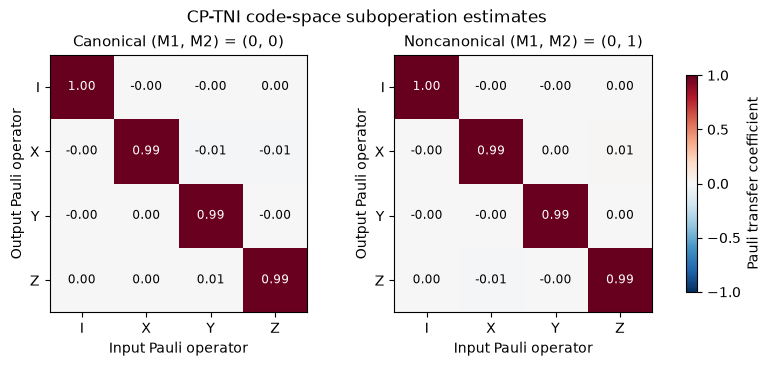

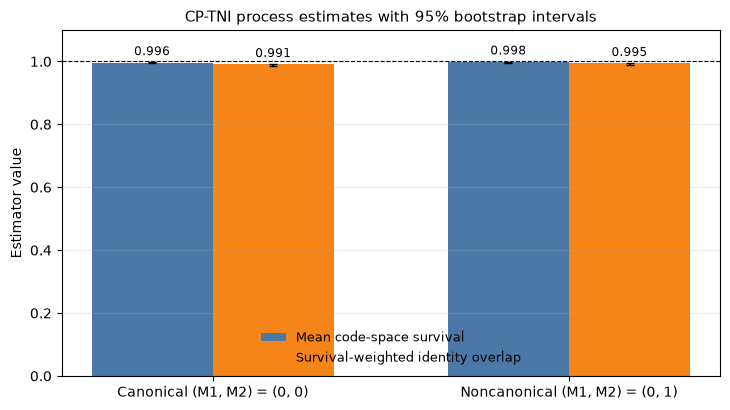

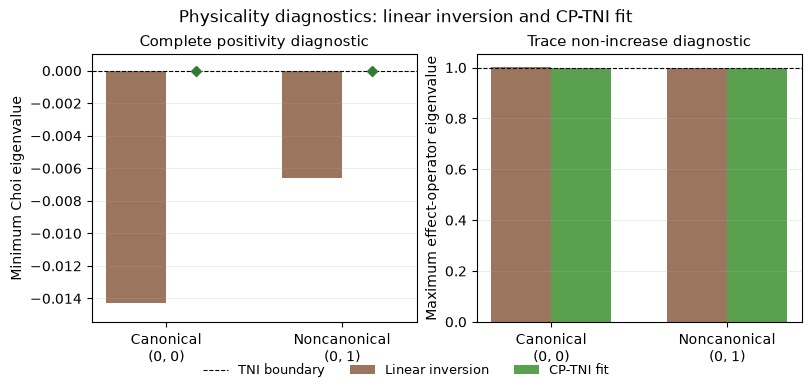

In [11]:
if RUN_LOCAL_VALIDATION:
    aer = AerSimulator()
    aer_circuits = transpile(combined_circuits, aer, optimization_level=1, seed_transpiler=RANDOM_SEED)
    aer_result = aer.run(aer_circuits, shots=LOCAL_SHOTS, seed_simulator=RANDOM_SEED).result()
    local_counts = [aer_result.get_counts(index) for index in range(len(aer_circuits))]
    local_state_summary, local_densities = analyze_state_tomography(
        combined_records, local_counts, LOCAL_STATE_BOOTSTRAP_SAMPLES
    )
    local_analyses = {
        name: reconstruct_process_resource(combined_records, local_counts, name)
        for name in RESOURCES
    }
    local_bootstrap = pd.concat([
        bootstrap_process_resource(
            combined_records, local_counts, name, LOCAL_PROCESS_BOOTSTRAP_SAMPLES
        ) for name in RESOURCES
    ], ignore_index=True)
    local_process_summary = summarize_process_analyses(local_analyses, local_bootstrap)
    display(local_state_summary.round(4))
    display(local_process_summary.round(6))
    plot_cptni_ptms(local_analyses, "local")
    plot_cptni_metrics(local_process_summary, "local")
    plot_physicality(local_analyses, "local")
    local_metadata = {
        "execution": "AerSimulator local validation",
        "shots_per_circuit": LOCAL_SHOTS,
        "circuits": len(combined_circuits),
        "state_bootstrap_samples": LOCAL_STATE_BOOTSTRAP_SAMPLES,
        "process_bootstrap_samples": LOCAL_PROCESS_BOOTSTRAP_SAMPLES,
        "random_seed": RANDOM_SEED,
        "resources": RESOURCES,
        "generated_utc": datetime.now(timezone.utc).isoformat(),
    }
    save_machine_readable_results(
        "local", combined_records, [local_counts], local_state_summary,
        local_analyses, local_bootstrap, local_process_summary, local_metadata
    )
    assert local_process_summary["cptni_minimum_choi_eigenvalue"].min() > -2e-5
    assert local_process_summary["cptni_maximum_effect_eigenvalue"].max() < 1 + 2e-5
    print("Local CP-TNI validation passed.")

## 9. IBM Quantum account and backend selection

If credentials are already saved, skip the credential-saving cell. Otherwise run it
once on a trusted computer. Running the backend-selection cell connects to IBM Quantum
but does not submit a job. Leave `BACKEND_NAME` blank for automatic least-busy selection,
or enter an exact backend name in Section 2 for a reproducible choice.


In [14]:
from getpass import getpass

# Run this cell only if IBM Quantum credentials have not already been saved.
api_key = getpass("IBM Cloud API key: ")
instance = input("Instance CRN or name (leave blank for automatic selection): ").strip()

account_options = {
    "token": api_key,
    "channel": "ibm_quantum_platform",
    "set_as_default": True,
    "overwrite": True,
}
if instance:
    account_options["instance"] = instance

QiskitRuntimeService.save_account(**account_options)
del api_key, account_options
print("IBM Quantum credentials saved.")


IBM Cloud API key:  ········
Instance CRN or name (leave blank for automatic selection):  crn:v1:bluemix:public:quantum-computing:us-east:a/6bc69b01301a4661a7c5dbf6e86b9170:ec4db732-8658-4a07-907b-aad22a692a7d::


IBM Quantum credentials saved.


In [15]:
service = QiskitRuntimeService()

if BACKEND_NAME.strip():
    backend = service.backend(BACKEND_NAME.strip())
else:
    backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=5,
    )

if getattr(backend.configuration(), "simulator", False):
    raise RuntimeError("A simulator was selected. Choose a real IBM Quantum backend.")

print("Selected real-hardware backend:", backend.name)
print("Pending jobs:", backend.status().pending_jobs)
print("Operational:", backend.status().operational)


Selected real-hardware backend: ibm_phoenix
Pending jobs: 0
Operational: True


## 10. Compile the single-backend combined batch and archive metadata

Run this cell after backend selection. It does not consume QPU time. Both resources
remain in one ordered manifest and are transpiled by one pass manager for the selected
real backend. The saved metadata include final layout, depth, two-qubit-gate count,
target information, and the contemporaneous backend-properties snapshot when available.


In [16]:
def final_layout_indices(circuit):
    layout = getattr(circuit, "layout", None)
    if layout is None:
        return None
    try:
        return [int(index) for index in layout.final_index_layout(filter_ancillas=True)]
    except Exception:
        return str(layout)


def backend_snapshot(backend):
    snapshot = {
        "backend_name": backend.name,
        "num_qubits": backend.num_qubits,
        "operation_names": sorted(getattr(backend, "operation_names", [])),
        "dt_seconds": getattr(backend, "dt", None),
        "captured_utc": datetime.now(timezone.utc).isoformat(),
    }
    coupling_map = getattr(backend, "coupling_map", None)
    if coupling_map is not None:
        try:
            snapshot["coupling_edges"] = coupling_map.get_edges()
        except Exception:
            snapshot["coupling_edges"] = str(coupling_map)
    try:
        properties = backend.properties()
        snapshot["properties"] = properties.to_dict() if properties is not None else None
    except Exception as exc:
        snapshot["properties_capture_error"] = repr(exc)
    return snapshot



hardware_pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, seed_transpiler=RANDOM_SEED
)
hardware_circuits = hardware_pm.run(combined_circuits)
compile_rows = []
for index, (record, compiled) in enumerate(zip(combined_records, hardware_circuits)):
    compile_rows.append({
        "manifest_index": index,
        **record,
        "depth": compiled.depth(),
        "two_qubit_gates": sum(
            count for gate, count in compiled.count_ops().items()
            if gate in {"cx", "cz", "ecr", "rzz", "iswap"}
        ),
        "final_layout": final_layout_indices(compiled),
    })
compile_table = pd.DataFrame(compile_rows)
compile_table.to_csv(OUTPUT_DIR / "hardware_combined_compile_metadata.csv", index=False)
snapshot = backend_snapshot(backend)
(OUTPUT_DIR / "hardware_backend_calibration_snapshot.json").write_text(
    json.dumps(snapshot, indent=2, default=str), encoding="utf-8"
)
display(compile_table.groupby(["experiment", "resource"])[["depth", "two_qubit_gates"]].agg(["min", "mean", "max"]).round(2))

print("Compiled real-hardware circuits:", len(hardware_circuits))
print("Backend:", backend.name)


depth            two_qubit_gates          
                          min   mean max             min  mean max
experiment resource                                               
process    canonical       54  56.33  57              19  19.0  19
           noncanonical    56  58.33  59              19  19.0  19
state      canonical       53  57.21  60              19  19.0  19
           noncanonical    53  57.58  60              19  19.0  19

Compiled real-hardware circuits: 216
Backend: ibm_phoenix


## 11. Submit the real-hardware batch

**Running the next cell consumes QPU time.** With the default settings, one repeat
contains 216 circuits x 4096 shots = 884,736 shots. Verify the printed backend,
shot count, repeat count, and account allocation before running it. The cell submits
both resources together to the selected IBM quantum computer.


In [17]:
# This cell submits the compiled circuits to a real IBM quantum computer.
print("Backend:", backend.name)
print("Circuits per repeat:", len(hardware_circuits))
print("Shots per circuit:", HARDWARE_SHOTS)
print("Repeats:", HARDWARE_REPEATS)
print("Total requested shots:", len(hardware_circuits) * HARDWARE_SHOTS * HARDWARE_REPEATS)

runtime_sampler = RuntimeSampler(mode=backend)
runtime_jobs = []
submitted_job_ids = []

for repeat_index in range(HARDWARE_REPEATS):
    job = runtime_sampler.run(hardware_circuits, shots=HARDWARE_SHOTS)
    runtime_jobs.append(job)
    submitted_job_ids.append(job.job_id())
    print(
        f"Submitted repeat {repeat_index + 1}/{HARDWARE_REPEATS}: "
        f"job_id={job.job_id()}, status={job.status()}"
    )

submission_record = {
    "backend": backend.name,
    "job_ids": submitted_job_ids,
    "shots_per_circuit_per_repeat": HARDWARE_SHOTS,
    "repeats": HARDWARE_REPEATS,
    "circuits_per_repeat": len(hardware_circuits),
    "resources": RESOURCES,
    "submitted_utc": datetime.now(timezone.utc).isoformat(),
}
job_record_path = OUTPUT_DIR / "hardware_combined_job_ids.json"
job_record_path.write_text(
    json.dumps(submission_record, indent=2),
    encoding="utf-8",
)
print("Saved job record:", job_record_path.resolve())


Backend: ibm_phoenix
Circuits per repeat: 216
Shots per circuit: 4096
Repeats: 1
Total requested shots: 884736
Submitted repeat 1/1: job_id=daj7e68mhr3c73e8kotg, status=QUEUED
Saved job record: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_combined_job_ids.json


## 12. Reconnect, retrieve, analyze, and export hardware results

After submission, run the reconnect cell. It works both in the current session and
after a kernel restart by reading the saved backend name and job IDs. Then run the
retrieval cell; it waits for completion, downloads counts, performs state tomography,
CP-TNI reconstruction, and bootstrap analysis, and exports the English figures and data.


In [18]:
job_record_path = OUTPUT_DIR / "hardware_combined_job_ids.json"
if not job_record_path.exists():
    raise FileNotFoundError(
        "No hardware job record was found. Run the real-hardware submission cell first."
    )

job_record = json.loads(job_record_path.read_text(encoding="utf-8"))
service = QiskitRuntimeService()
backend = service.backend(job_record["backend"])
submitted_job_ids = job_record["job_ids"]
runtime_jobs = [service.job(job_id) for job_id in submitted_job_ids]

print("Reconnected backend:", backend.name)
print("Reconnected job IDs:", submitted_job_ids)
for job in runtime_jobs:
    print(job.job_id(), job.status())


Reconnected backend: ibm_phoenix
Reconnected job IDs: ['daj7e68mhr3c73e8kotg']
daj7e68mhr3c73e8kotg RUNNING


Waiting for repeat 1: job_id=daj7e68mhr3c73e8kotg
Repeat 1 completed with 216 circuit results.


,resource,M1,M2,case,x,m,raw_fidelity_to_input,raw_fidelity_to_predicted_frame,frame_tracked_fidelity_to_input,recovered_fidelity_to_input,recovered_code_population,recovered_purity,recovered_coherence_real,recovered_coherence_imag,raw_fidelity_to_predicted_frame_ci95_low,raw_fidelity_to_predicted_frame_ci95_high,frame_tracked_fidelity_to_input_ci95_low,frame_tracked_fidelity_to_input_ci95_high,recovered_fidelity_to_input_ci95_low,recovered_fidelity_to_input_ci95_high
0,canonical,0,0,"(0,0)",0,0,0.8925,0.8925,0.8925,0.9013,0.9304,0.8321,0.2584,-0.2990,0.8834,0.9026,0.8834,0.9026,0.8909,0.9099
1,canonical,0,0,"(1,0)",1,0,0.0642,0.8879,0.8879,0.8800,0.9099,0.8001,0.2656,-0.2859,0.8779,0.8960,0.8779,0.8960,0.8706,0.8892
2,canonical,0,0,"(0,1)",0,1,0.2749,0.8631,0.8631,0.8667,0.9033,0.7796,0.2552,-0.2795,0.8544,0.8743,0.8544,0.8743,0.8567,0.8760
3,canonical,0,0,"(1,1)",1,1,0.0433,0.8884,0.8884,0.8959,0.9229,0.8301,0.2637,-0.2909,0.8785,0.8981,0.8785,0.8981,0.8868,0.9051
4,noncanonical,0,1,"(0,0)",0,0,0.0152,0.9175,0.9175,0.9210,0.9475,0.8671,0.2671,-0.3081,0.9076,0.9265,0.9076,0.9265,0.9117,0.9294
5,noncanonical,0,1,"(1,0)",1,0,0.5067,0.9011,0.9011,0.8980,0.9294,0.8267,0.2610,-0.2981,0.8916,0.9105,0.8916,0.9105,0.8880,0.9085
6,noncanonical,0,1,"(0,1)",0,1,0.0320,0.8945,0.8945,0.9015,0.9412,0.8356,0.2673,-0.2887,0.8846,0.9041,0.8846,0.9041,0.8932,0.9108
7,noncanonical,0,1,"(1,1)",1,1,0.2008,0.9257,0.9257,0.9238,0.9592,0.8750,0.2727,-0.3010,0.9167,0.9353,0.9167,0.9353,0.9150,0.9319


,resource,M1,M2,process_case,linear_mean_survival,linear_survival_weighted_identity_overlap,linear_minimum_choi_eigenvalue,linear_maximum_effect_eigenvalue,cptni_mean_survival,cptni_survival_weighted_identity_overlap,cptni_minimum_choi_eigenvalue,cptni_maximum_effect_eigenvalue,solver_status,least_squares_objective,cptni_mean_survival_ci95_low,cptni_mean_survival_ci95_high,cptni_survival_weighted_identity_overlap_ci95_low,cptni_survival_weighted_identity_overlap_ci95_high
0,canonical,0,0,"(1, 0)",0.902954,0.855916,-0.008311,0.915491,0.905289,0.855941,0.000000,0.917907,optimal,0.000031,0.899292,0.912278,0.849549,0.862343
1,noncanonical,0,1,"(0, 0)",0.950562,0.918457,0.003741,0.962574,0.950562,0.918457,0.003741,0.962574,optimal,0.000000,0.947167,0.956574,0.912146,0.924185


Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_ptm_comparison.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_ptm_comparison.pdf
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_metrics_bootstrap.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_metrics_bootstrap.pdf
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_physicality.png
Saved: C:\Users\hideok34\canonical_noncanonical_cptni_results\hardware_same_backend_cptni_physicality.pdf
Hardware analysis and publication files completed.


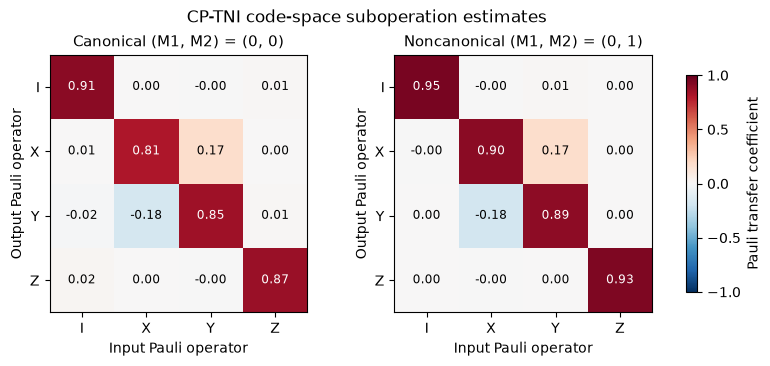

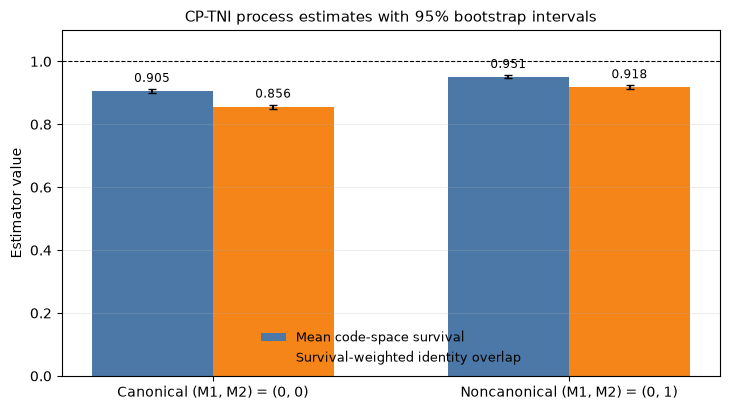

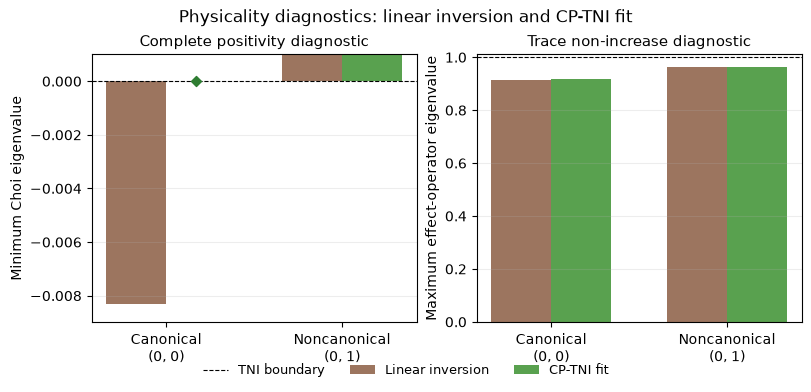

In [19]:
hardware_repeated_counts = []
for repeat_index, job in enumerate(runtime_jobs, start=1):
    print(f"Waiting for repeat {repeat_index}: job_id={job.job_id()}")
    result = job.result()
    counts = [
        result[index].data.meas.get_counts()
        for index in range(len(combined_records))
    ]
    if len(counts) != len(combined_records):
        raise RuntimeError(
            f"Expected {len(combined_records)} circuit results, received {len(counts)}."
        )
    hardware_repeated_counts.append(counts)
    print(f"Repeat {repeat_index} completed with {len(counts)} circuit results.")

pooled_hardware_counts = pool_repeated_counts(hardware_repeated_counts)
hardware_state_summary, hardware_densities = analyze_state_tomography(
    combined_records,
    pooled_hardware_counts,
    HARDWARE_STATE_BOOTSTRAP_SAMPLES,
)
hardware_analyses = {
    name: reconstruct_process_resource(combined_records, pooled_hardware_counts, name)
    for name in RESOURCES
}
hardware_bootstrap = pd.concat(
    [
        bootstrap_process_resource(
            combined_records,
            pooled_hardware_counts,
            name,
            HARDWARE_PROCESS_BOOTSTRAP_SAMPLES,
        )
        for name in RESOURCES
    ],
    ignore_index=True,
)
hardware_process_summary = summarize_process_analyses(
    hardware_analyses,
    hardware_bootstrap,
)

display(hardware_state_summary.round(4))
display(hardware_process_summary.round(6))
plot_cptni_ptms(hardware_analyses, "hardware_same_backend")
plot_cptni_metrics(hardware_process_summary, "hardware_same_backend")
plot_physicality(hardware_analyses, "hardware_same_backend")

hardware_metadata = {
    "experiment": "Same-backend canonical and noncanonical state tomography with CP-TNI code-space reconstruction",
    "backend": backend.name,
    "job_ids": submitted_job_ids,
    "shots_per_circuit_per_repeat": HARDWARE_SHOTS,
    "repeats": len(hardware_repeated_counts),
    "circuits_per_repeat": len(combined_records),
    "receiver_order": ["q4", "q3"],
    "state_input": "sqrt(0.7)|00> + exp(i*pi/3)*sqrt(0.3)|11>",
    "process_inputs": list(PROCESS_INPUTS),
    "resources": RESOURCES,
    "tomography_bases": list(TOMOGRAPHY_BASES),
    "state_bootstrap_samples": HARDWARE_STATE_BOOTSTRAP_SAMPLES,
    "process_bootstrap_samples": HARDWARE_PROCESS_BOOTSTRAP_SAMPLES,
    "bootstrap_scope": "Finite-shot multinomial uncertainty conditional on the pooled submitted jobs; not run-to-run drift",
    "error_mitigation": "None",
    "spam_separation": "None",
    "cptni_estimator": "Convex least-squares Choi fit with J >= 0 and Tr_out(J) <= I",
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}
save_machine_readable_results(
    "hardware_same_backend",
    combined_records,
    hardware_repeated_counts,
    hardware_state_summary,
    hardware_analyses,
    hardware_bootstrap,
    hardware_process_summary,
    hardware_metadata,
)
print("Hardware analysis and publication files completed.")


## 13. Reporting checklist for the manuscript

Report the following points explicitly:

- canonical and noncanonical circuits were executed on the same backend and in
  the same combined acquisition batch;
- the process fit uses unnormalized code blocks, so code-space loss remains in
  the trace row;
- the primary estimator is CP-TNI constrained; unconstrained linear inversion is
  retained only as a diagnostic;
- the survival-weighted identity overlap is not a conditional CPTP process fidelity;
- 95% intervals are multinomial finite-shot bootstrap intervals for the submitted
  batch and do not measure day-to-day drift;
- no error mitigation or SPAM separation was applied unless the experiment is
  intentionally rerun with such procedures;
- report backend name, job IDs, shot count, Qiskit versions, final layouts,
  circuit depths, two-qubit-gate counts, and calibration-snapshot timestamp;
- do not interpret a numerical canonical/noncanonical difference as intrinsic
  resource robustness without independent same-backend repeats.